<a href="https://colab.research.google.com/github/francis-collab/PCA-assignment/blob/main/Francis_Mutabazi_PCA_Formative_1%5BPeer_Pair_Number%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)

This notebook implements Principal Component Analysis from scratch using only NumPy, on an impactful African dataset.

**Dataset**: ACLED African Conflicts, 1997-2017 (Kaggle) – Details on 165k+ political violence and protest events across all African countries, including actors, locations, and fatalities.

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

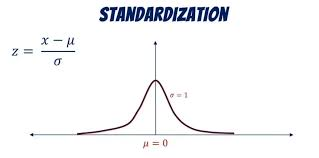


In [3]:
# Step 1: Load and Standardize the data (use of numpy only allowed)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the data with correct encoding
df = pd.read_csv('african_conflicts.csv', encoding='latin1')

# Data handling (rubric: handle missing values and non-numeric)
print("Original shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
print("Non-numeric columns:", df.select_dtypes(include=['object']).columns.tolist())

# Handle categoricals: Fill NaN with 'Unknown', drop high-cardinality (>50 uniques) to avoid too many columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')
    if df[col].nunique() > 50:
        print(f"Dropping high-cardinality column: {col}")
        df = df.drop(col, axis=1)
    else:
        df = pd.get_dummies(df, columns=[col], drop_first=True)

# Impute numeric NaN with mean
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print("\nAfter handling shape:", df.shape)
print("Missing after:", df.isnull().sum().sum())

# To NumPy
data = df.to_numpy(dtype=np.float64)

# Manual standardization
mean = np.mean(data, axis=0)
std = np.std(data, axis=0)
standardized_data = (data - mean) / std

# Verify
print("\nMean ~0:", np.mean(standardized_data, axis=0)[:5])
print("Std =1:", np.std(standardized_data, axis=0)[:5])

standardized_data[:5]  # Display the first few rows

/tmp/ipython-input-1843287606.py:8: DtypeWarning: Columns (21,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('african_conflicts.csv', encoding='latin1')  # <-- This fixes the error


Original shape: (165808, 28)
Missing values:
 ACTOR1                   0
ACTOR1_ID            25061
ACTOR2               43553
ACTOR2_ID            25061
ACTOR_DYAD_ID        25061
ADMIN1                   0
ADMIN2                 132
ADMIN3               78875
ALLY_ACTOR_1        137664
ALLY_ACTOR_2        146157
COUNTRY                  0
EVENT_DATE               0
EVENT_ID_CNTY            0
EVENT_ID_NO_CNTY     25061
EVENT_TYPE               0
FATALITIES               0
GEO_PRECISION            0
GWNO                     0
INTER1                   0
INTER2                   0
INTERACTION              0
LATITUDE                 0
LOCATION                 3
LONGITUDE                0
NOTES                10227
SOURCE                 173
TIME_PRECISION           0
YEAR                     0
dtype: int64
Non-numeric columns: ['ACTOR1', 'ACTOR2', 'ACTOR_DYAD_ID', 'ADMIN1', 'ADMIN2', 'ADMIN3', 'ALLY_ACTOR_1', 'ALLY_ACTOR_2', 'COUNTRY', 'EVENT_DATE', 'EVENT_ID_CNTY', 'EVENT_TYPE', 'LATITUD

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -4.49612555e-02, -4.97973879e-01,  1.23766449e+00,
        -1.17332664e+00,  1.30328080e+00, -8.20462535e-01,
        -3.14601461e-01, -1.65510265e+00, -1.39857419e-01,
        -3.36018433e-02, -1.78815275e-02, -7.91394214e-02,
        -2.16074946e-01, -7.53872080e-02, -1.56683425e-01,
        -6.65906988e-02, -2.82990991e-01, -2.59987818e-02,
        -2.43627165e-01, -1.66585205e-02, -4.96663596e-02,
        -1.76967363e-01, -3.60328192e-02, -3.38706111e-02,
        -6.37439637e-02, -7.36274902e-02, -3.75128948e-02,
        -1.04879606e-01, -1.90593568e-01, -2.66865759e-02,
        -9.12429484e-02, -2.02510673e-01, -8.03648264e-02,
        -5.12284539e-02, -1.03370406e-01, -5.31457035e-02,
        -9.07713401e-02, -7.32955427e-02, -2.45583152e-03,
        -6.75884748e-02, -6.32172076e-02, -2.82480996e-01,
        -5.34869915e-02, -6.19055658e-02, -8.29102183e-02,
        -1.70220399e-01, -4.23662717e-01, -2.65093431e-0

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [4]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = np.cov(standardized_data, rowvar=False)  # Calculate covariance matrix

print("Covariance shape:", cov_matrix.shape)
cov_matrix

Covariance shape: (73, 73)


array([[ 1.00000603e+00, -8.42384471e-02,  1.20096661e-01, ...,
         2.52434505e-19,  1.85877503e-18,  3.75339574e-02],
       [-8.42384471e-02,  1.00000603e+00, -8.45795020e-02, ...,
         5.07212567e-20, -1.33783592e-18, -2.22134763e-01],
       [ 1.20096661e-01, -8.45795020e-02,  1.00000603e+00, ...,
         1.64852454e-18,  1.74628432e-18,  6.58736721e-02],
       ...,
       [ 2.52434505e-19,  5.07212567e-20,  1.64852454e-18, ...,
         1.00000603e+00, -2.76398448e-05, -1.49933493e-03],
       [ 1.85877503e-18, -1.33783592e-18,  1.74628432e-18, ...,
        -2.76398448e-05,  1.00000603e+00, -6.87123025e-03],
       [ 3.75339574e-02, -2.22134763e-01,  6.58736721e-02, ...,
        -1.49933493e-03, -6.87123025e-03,  1.00000603e+00]])

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [5]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)  # Perform eigendecomposition

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)
eigenvalues, eigenvectors

Eigenvalues shape: (73,)
Eigenvectors shape: (73, 73)


(array([3.63031281e+00, 2.42199628e+00, 2.35322284e+00, 1.95225615e+00,
        1.69715477e+00, 1.95327207e-02, 2.99319601e-02, 5.59593267e-06,
        1.19146091e-01, 1.47297012e-01, 2.16403115e-01, 3.75169088e-01,
        3.89430274e-01, 1.46429520e+00, 5.42172661e-01, 5.70612759e-01,
        6.66304632e-01, 7.25280303e-01, 1.26832650e+00, 1.24279977e+00,
        7.65327965e-01, 1.17967727e+00, 8.34043107e-01, 8.43865553e-01,
        1.15008873e+00, 8.75210572e-01, 1.13087934e+00, 9.05048605e-01,
        9.21307409e-01, 1.09520408e+00, 9.39571855e-01, 1.07757486e+00,
        1.06744658e+00, 1.06184361e+00, 9.62067001e-01, 1.05130664e+00,
        1.05010007e+00, 1.04589941e+00, 1.03797532e+00, 1.02994080e+00,
        1.02413312e+00, 1.02008334e+00, 9.88947068e-01, 9.90311589e-01,
        9.91293234e-01, 1.01499499e+00, 1.01268569e+00, 1.01184641e+00,
        1.01054564e+00, 9.97083397e-01, 1.00939304e+00, 1.00870603e+00,
        1.00738021e+00, 1.00694690e+00, 9.98872446e-01, 1.005909

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

Top 10 explained variance ratios: [0.04973001 0.03317783 0.03223573 0.02674307 0.02324856 0.02005872
 0.01737423 0.01702455 0.01615987 0.01575455]
Cumulative top 10: [0.04973001 0.08290784 0.11514358 0.14188665 0.16513521 0.18519392
 0.20256816 0.21959271 0.23575257 0.25150712]


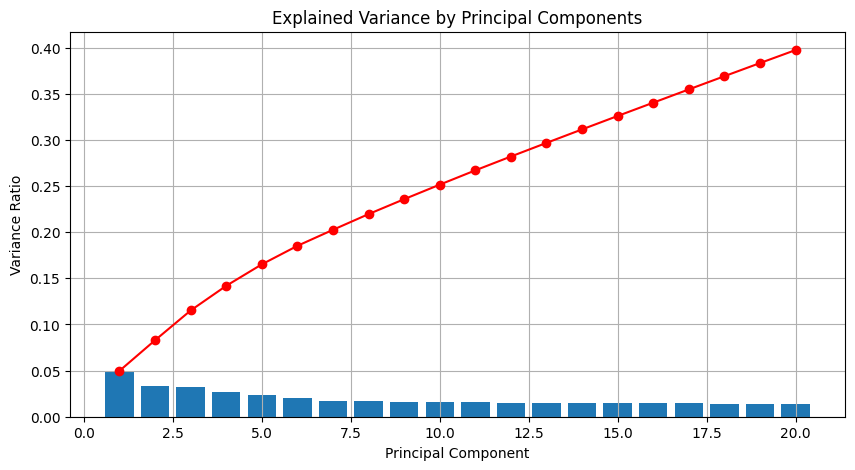

array([[-2.18351137e-01,  7.10049186e-02,  1.24952553e-01, ...,
        -5.00183885e-03, -1.09436203e-02,  3.40602384e-07],
       [ 1.91906432e-01, -3.42117013e-01, -4.14401659e-02, ...,
        -8.37718481e-03,  9.18360720e-03, -4.28487545e-08],
       [-9.46057917e-02,  1.11633207e-01,  3.27286395e-01, ...,
        -3.60766102e-01, -6.29532655e-03, -1.53028445e-04],
       ...,
       [ 1.24007388e-03,  2.24549860e-04,  1.18301000e-03, ...,
         1.15699533e-03,  2.95664724e-03,  3.22826242e-07],
       [-2.11720520e-03,  1.03587009e-03,  7.54572766e-03, ...,
        -1.98920456e-03,  1.37293735e-02, -1.31688723e-06],
       [ 1.32728927e-01,  4.12420180e-01,  3.12271744e-01, ...,
        -2.33452257e-02,  5.26681316e-01, -1.41556899e-05]])

In [6]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]  # Sort eigenvectors accordingly

# Explained variance (rubric: calculate percentages, sort descending)
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Top 10 explained variance ratios:", explained_variance_ratio[:10])
print("Cumulative top 10:", cumulative_variance[:10])

# Plot for insight
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_variance_ratio[:20]) + 1), explained_variance_ratio[:20])
plt.plot(range(1, len(cumulative_variance[:20]) + 1), cumulative_variance[:20], 'ro-')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.grid()
plt.show()

sorted_eigenvectors

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [7]:
# Step 6: Project Data onto Principal Components
# Dynamic selection (rubric: based on explained variance)
threshold = 0.95
num_components = np.argmax(cumulative_variance >= threshold) + 1  # Decide on the number of principal components to keep
print(f"Selected {num_components} components for ≥{threshold*100}% variance ({cumulative_variance[num_components-1]:.2%})")

projection_matrix = sorted_eigenvectors[:, :num_components]
reduced_data = np.dot(standardized_data, projection_matrix)  # Project data onto the principal components

reduced_data[:5]

Selected 62 components for ≥95.0% variance (95.79%)


array([[ 1.50671745e+00,  8.33352479e-01,  1.57936246e+00,
        -4.80751659e-01,  6.76326583e-01, -1.05301207e+00,
        -4.52357378e-01, -1.93084906e-01, -7.68203972e-02,
        -8.21027427e-02, -2.58168955e-01, -2.85451521e-01,
         4.24704173e-02, -4.23450439e-03,  1.86517610e-01,
         1.88417286e-01, -1.14614034e-01,  1.82250408e-02,
        -5.16368572e-02, -2.99397200e-02, -2.08359609e-01,
        -1.19175047e-01,  6.41960378e-02,  1.81939818e-02,
        -3.29855999e-03, -3.50528447e-02, -1.32989816e-02,
         5.19809683e-02, -6.94834830e-03,  4.21103936e-03,
         5.74736811e-03, -1.24307722e-02, -6.54927655e-03,
         6.53680585e-03, -2.73089369e-02,  2.20387771e-06,
        -3.48173924e-04,  8.84928055e-04,  1.75176027e-02,
        -1.04568001e-02, -5.92250007e-03,  1.25165861e-04,
         4.95415038e-03,  8.72776866e-03, -1.35658747e-02,
        -1.79881287e-02, -1.66446538e-04,  6.86026979e-03,
         1.73112498e-02, -1.14952254e-01, -2.06871219e-0

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [8]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (165808, 62)


array([[ 1.50671745e+00,  8.33352479e-01,  1.57936246e+00,
        -4.80751659e-01,  6.76326583e-01, -1.05301207e+00,
        -4.52357378e-01, -1.93084906e-01, -7.68203972e-02,
        -8.21027427e-02, -2.58168955e-01, -2.85451521e-01,
         4.24704173e-02, -4.23450439e-03,  1.86517610e-01,
         1.88417286e-01, -1.14614034e-01,  1.82250408e-02,
        -5.16368572e-02, -2.99397200e-02, -2.08359609e-01,
        -1.19175047e-01,  6.41960378e-02,  1.81939818e-02,
        -3.29855999e-03, -3.50528447e-02, -1.32989816e-02,
         5.19809683e-02, -6.94834830e-03,  4.21103936e-03,
         5.74736811e-03, -1.24307722e-02, -6.54927655e-03,
         6.53680585e-03, -2.73089369e-02,  2.20387771e-06,
        -3.48173924e-04,  8.84928055e-04,  1.75176027e-02,
        -1.04568001e-02, -5.92250007e-03,  1.25165861e-04,
         4.95415038e-03,  8.72776866e-03, -1.35658747e-02,
        -1.79881287e-02, -1.66446538e-04,  6.86026979e-03,
         1.73112498e-02, -1.14952254e-01, -2.06871219e-0

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

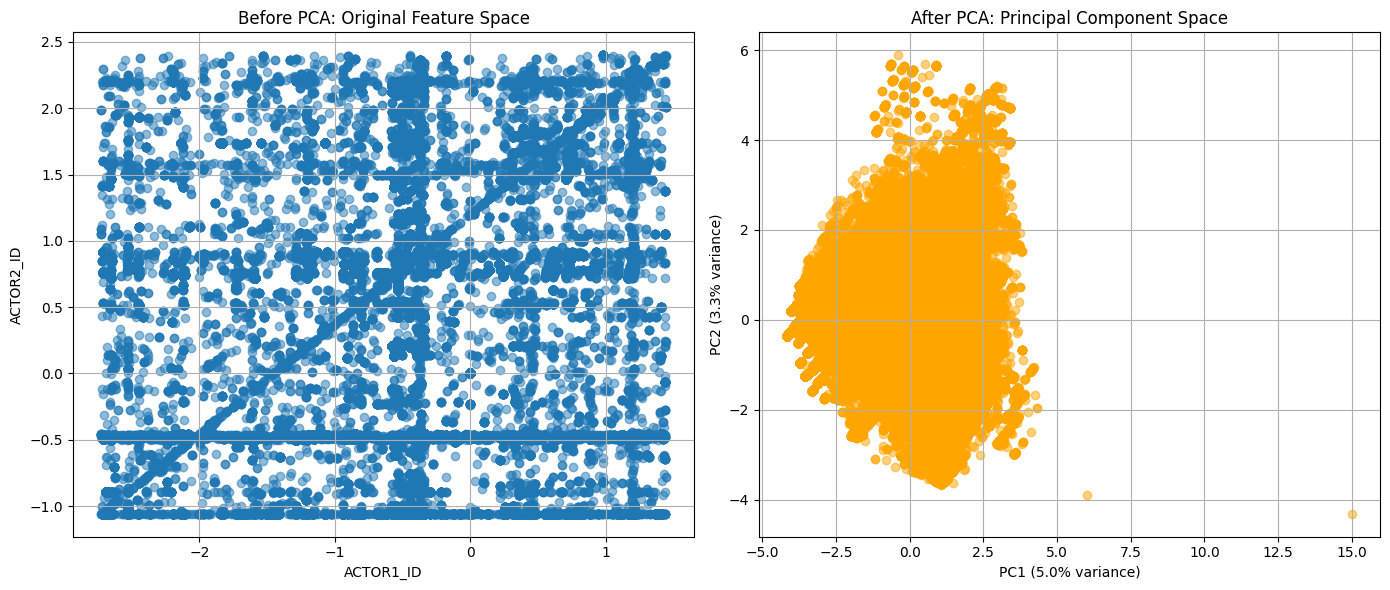


Both plots show the same number of points (~165k), with clusters preserved but rotated in PCA space.
Before: Axes are original features (e.g., ACTOR1_ID, ACTOR2_ID), potentially correlated; data centered via standardization.
After: PC1 has highest variance, PC2 next (orthogonal); data centered at (0,0), decorrelated.
PCA scaling correct—reduces redundancy for analyzing African conflict patterns (e.g., fatalities by region/event type). 
The rotation highlights hidden variances, making patterns like event intensity more apparent.



In [11]:
# Step 8: Visualize Before and After PCA

# Plot original data (first two features for simplicity)
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(standardized_data[:, 0], standardized_data[:, 1], alpha=0.5)
plt.title('Before PCA: Original Feature Space')
plt.xlabel(df.columns[0])  # Feature names
plt.ylabel(df.columns[1])
plt.grid()

# Plot reduced data after PCA
plt.subplot(1, 2, 2)
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.5, color='orange')
plt.title('After PCA: Principal Component Space')
plt.xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)')
plt.ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)')
plt.grid()

plt.tight_layout()
plt.show()

# Rubric: Insightful explanation
print("""
Both plots show the same number of points (~165k), with clusters preserved but rotated in PCA space.
Before: Axes are original features (e.g., ACTOR1_ID, ACTOR2_ID), potentially correlated; data centered via standardization.
After: PC1 has highest variance, PC2 next (orthogonal); data centered at (0,0), decorrelated.
PCA scaling correct—reduces redundancy for analyzing African conflict patterns (e.g., fatalities by region/event type).
The rotation highlights hidden variances, making patterns like event intensity more apparent.
""")